<a href="https://colab.research.google.com/github/RabinPhuyal/Deep-Learning-with-Pytorch/blob/main/Pytorch_WorkFlow_Fundamentals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Running Tensor on GPUs

In [2]:
#Getting a GPU
!nvidia-smi

Fri May 22 14:45:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# Check for GPU
import torch
torch.cuda.is_available()

True

In [4]:
#Set Device Type
import torch

device ="cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [5]:
#Count number of devices
torch.cuda.device_count()

1

In [6]:
#Getting Pytorch to run on Apple Silicon

#check for Apple Silicon GPU
import torch
torch.backends.mps.is_available() # Note this will print false if you're not running on a Mac

False

In [7]:
#set device type
device = "mps" if torch.backends.mps.is_available() else "cpu"
device

'cpu'

In [8]:
if torch.cuda.is_available():
  device="cuda"
elif torch.backends.mps.is_available():
  device="mps"
else:
  device = "cpu"
device

'cuda'

In [9]:
#Create tensor (default on CPU)
tensor = torch.tensor([1,2,3])

#Tensor not on gpu
print(tensor,tensor.device)

tensor_on_gpu = tensor.to(device)
tensor_on_gpu

tensor([1, 2, 3]) cpu


tensor([1, 2, 3], device='cuda:0')

In [10]:
#Getting back to cpu
tensor_back_on_cpu = tensor_on_gpu.cpu().numpy()
tensor_back_on_cpu

array([1, 2, 3])

In [11]:
tensor_on_gpu

tensor([1, 2, 3], device='cuda:0')

In [12]:
#Python WorkFlow Fundamentals

In [13]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.10.0+cu128'

In [14]:
#Lets create a linear regression

#Staring with known parameters
weight = 0.7
bias = 0.3

#Create a data
start = 0
end = 1
step = 0.02

X = torch.arange(start,end,step).unsqueeze(dim=1)
y = weight*X+bias

X[:10],y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [15]:
#Splitting data into training and testing sets

train_split = int(0.8*len(X))

X_train,y_train = X[:train_split],y[:train_split]
X_test,y_test = X[train_split:],y[train_split:]

len(X_train),len(y_train),len(X_test),len(y_test)

(40, 40, 10, 10)

In [16]:
#Create a function to visualize it

def plot_predictions(train_data =  X_train,train_labels=y_train,test_data=X_test,test_labels=y_test,predictions=None):
  plt.figure(figsize=(10,7))

  #Scatter plot for training data in Blue
  plt.scatter(train_data,train_labels,c="b",s=4,label="Training Data")

  #Scatter plot for testing data in Green
  plt.scatter(test_data,test_labels,c="g",s=4,label="Testing Data")

  #Scatter plot for prediction in Red
  if predictions is not None:
    plt.scatter(test_data,predictions,c="r",s=4,label="Predictions")

  plt.legend(prop={"size":14})
  plt.show()

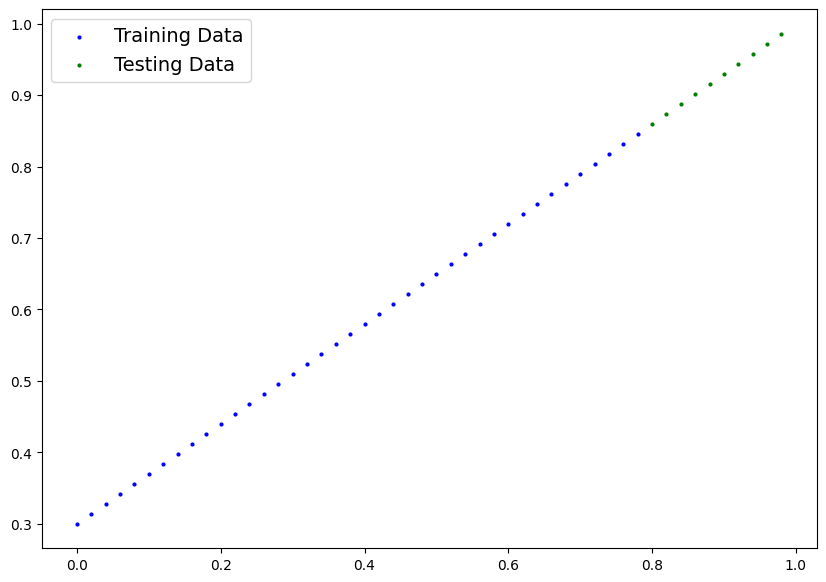

In [17]:
plot_predictions()

In [18]:
# Create a Linear Regression model class
class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch is a nn.Module (think of this as neural network lego blocks)
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, # <- start with random weights (this will get adjusted as the model learns)
                                                dtype=torch.float), # <- PyTorch loves float32 by default
                                   requires_grad=True) # <- can we update this value with gradient descent?)

        self.bias = nn.Parameter(torch.randn(1, # <- start with random bias (this will get adjusted as the model learns)
                                            dtype=torch.float), # <- PyTorch loves float32 by default
                                requires_grad=True) # <- can we update this value with gradient descent?))

    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" is the input data (e.g. training/testing features)
        return self.weights * x + self.bias # <- this is the linear regression formula (y = m*x + b)

In [19]:
#Set manual seed since nn.Parameter are randomly initialized

torch.manual_seed(42)

#Create an instance of the model
model_0 = LinearRegressionModel()

#Check the nn.Parameter(s) within the nn.Module subclass we created
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [20]:
#get the state using state_dict()
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [21]:
#Make predictions with the model
with torch.inference_mode():
  y_pred = model_0(X_test)

In [22]:
#Checking the predictions
print(f"Number of Testing samples: {len(X_test)}")
print(f"Number of Prediction made: {len(y_pred)}")
print(f"Predcition Values:\n{y_pred}")

Number of Testing samples: 10
Number of Prediction made: 10
Predcition Values:
tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


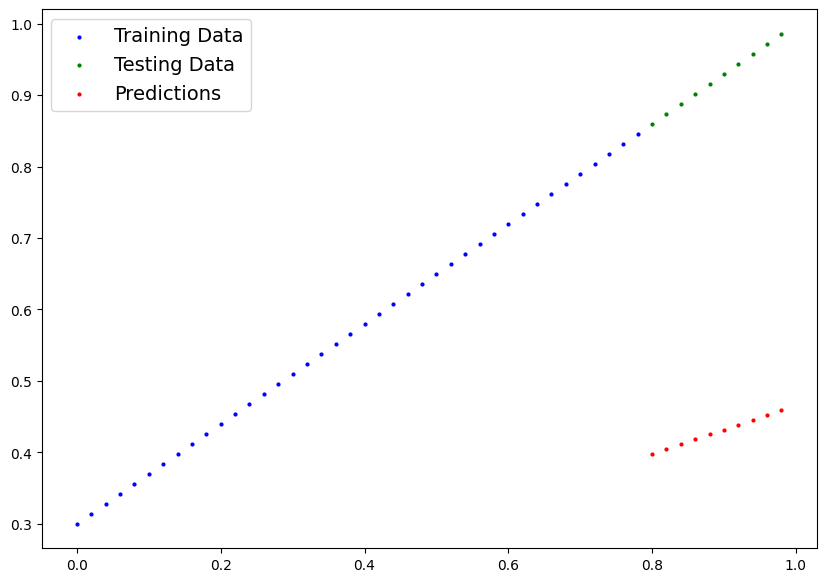

In [23]:
#Visualize the predictions
plot_predictions(predictions=y_pred)

In [24]:
y_test-y_pred

tensor([[0.4618],
        [0.4691],
        [0.4764],
        [0.4836],
        [0.4909],
        [0.4982],
        [0.5054],
        [0.5127],
        [0.5200],
        [0.5272]])

In [25]:
#Create the loss function

loss_fn = nn.L1Loss()

#Create the optimizer

optimizer = torch.optim.SGD(params=model_0.parameters(),lr=0.01)

In [28]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 100

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Caculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 0.31288138031959534 | MAE Test Loss: 0.48106518387794495 
Epoch: 10 | MAE Train Loss: 0.1976713240146637 | MAE Test Loss: 0.3463551998138428 
Epoch: 20 | MAE Train Loss: 0.08908725529909134 | MAE Test Loss: 0.21729660034179688 
Epoch: 30 | MAE Train Loss: 0.053148526698350906 | MAE Test Loss: 0.14464017748832703 
Epoch: 40 | MAE Train Loss: 0.04543796554207802 | MAE Test Loss: 0.11360953003168106 
Epoch: 50 | MAE Train Loss: 0.04167863354086876 | MAE Test Loss: 0.09919948130846024 
Epoch: 60 | MAE Train Loss: 0.03818932920694351 | MAE Test Loss: 0.08886633068323135 
Epoch: 70 | MAE Train Loss: 0.03476089984178543 | MAE Test Loss: 0.0805937647819519 
Epoch: 80 | MAE Train Loss: 0.03132382780313492 | MAE Test Loss: 0.07232122868299484 
Epoch: 90 | MAE Train Loss: 0.02788739837706089 | MAE Test Loss: 0.06473556160926819 


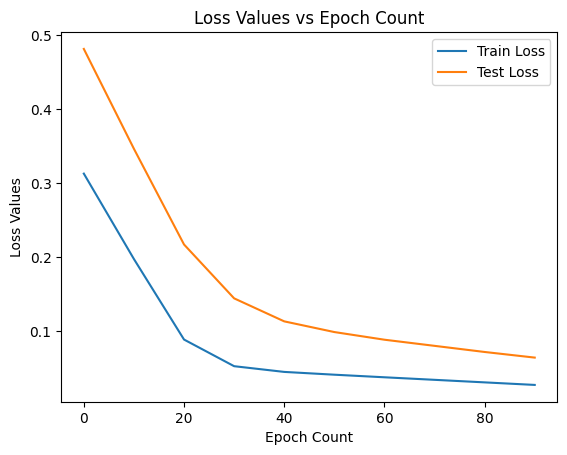

In [30]:
#Plot the loss curves values
plt.plot(epoch_count,train_loss_values,label = "Train Loss")
plt.plot(epoch_count,test_loss_values,label="Test Loss")
plt.ylabel("Loss Values")
plt.xlabel("Epoch Count")
plt.title("Loss Values vs Epoch Count")
plt.legend()